In [1]:
%pip install --quiet python-dotenv pydantic-ai

import os
from pathlib import Path
import nest_asyncio; nest_asyncio.apply()

# Download data files if not already present (e.g. on Colab)
if not Path("data").exists():
    import zipfile, urllib.request
    url = "https://github.com/jsoma/workshop-ai-images-video/raw/main/docs/nicar-2026/01-images-data.zip"
    print("Downloading data...")
    urllib.request.urlretrieve(url, "_data.zip")
    with zipfile.ZipFile("_data.zip") as zf:
        zf.extractall("data")
    Path("_data.zip").unlink()
    print("Done!")

# Load API keys: Colab secrets or local .env
try:
    from google.colab import userdata
    os.environ.setdefault("GOOGLE_API_KEY", userdata.get("GOOGLE_API_KEY"))
except ImportError:
    from dotenv import load_dotenv
    load_dotenv()

DATA = Path("data")
Path("outputs").mkdir(exist_ok=True)


Note: you may need to restart the kernel to use updated packages.


# Images

You already know what to do with text: summarize it, answer questions about it, extract data from it. Images, audio, and video are just ways of **getting to text and structured data.**

## Structured output

Send an image to an LLM and get back structured data — fields you can sort, filter, and verify. Not prose. This is the pattern for everything else in the workshop.


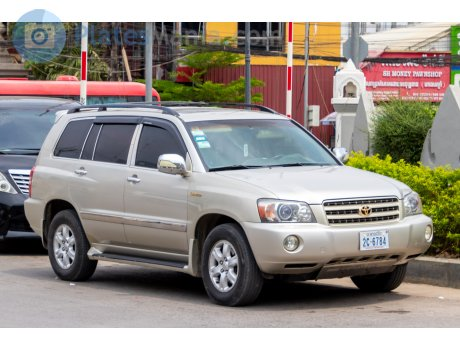

In [2]:
from IPython.display import Image
Image(filename="data/car.jpg", width=500)


**`vision-llm/structured.py`** — Send one image to an LLM, get structured Pydantic data back


In [3]:
from pathlib import Path

from pydantic import BaseModel, Field
from pydantic_ai import Agent, BinaryContent

MODEL = "openai:gpt-4o-mini"
DATA = Path("data")

class Vehicle(BaseModel):
    make: str = Field(description="Vehicle manufacturer (e.g., Toyota, Ford)")
    model: str = Field(description="Vehicle model name (e.g., Camry, F-150)")
    color: str = Field(description="Primary color of the vehicle")
    year_estimate: int = Field(description="Estimated model year (best guess)")
    vehicle_type: str = Field(description="Type: sedan, SUV, truck, van, motorcycle, etc.")
    confidence: float = Field(description="Your confidence in this identification, 0.0 to 1.0")

agent = Agent(MODEL, output_type=Vehicle)
result = agent.run_sync([
    "Analyze the vehicle in this image. Fill in all fields accurately.",
    BinaryContent(data=(DATA / "car.jpg").read_bytes(), media_type="image/jpeg"),
])
result.output


Vehicle(make='Toyota', model='Highlander', color='Silver', year_estimate=2004, vehicle_type='SUV', confidence=0.9)

Notice the Pydantic model: each field has a name, a type, and a description. The LLM fills in the fields. If it's wrong, you can see *which* field is wrong.

## Without structured output

Same image, same question, but the answer comes back as plain text. Easy to read, hard to sort or filter across hundreds of images.


**`vision-llm/raw-openai-text.py`** — Same task using raw OpenAI client, plain text response — no structured output


In [4]:
import base64
from pathlib import Path

from openai import OpenAI

MODEL = "gpt-4o-mini"
DATA = Path("data")

client = OpenAI()
base64_image = base64.b64encode((DATA / "car.jpg").read_bytes()).decode("utf-8")

prompt = """List the following about this vehicle:
- make
- model
- color
- estimated year
"""

response = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": [
        {"type": "text", "text": prompt},
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}},
    ]}],
)
print(response.choices[0].message.content)


Based on the vehicle seen in the image, here are the details:

- **Make**: Toyota
- **Model**: Highlander
- **Color**: Beige or Light Gold
- **Estimated Year**: 2001-2007 (common production years for this model)


## Batch processing

Same thing, whole folder. Out comes a CSV.


**`vision-llm/batch.py`** — Process a folder of images into structured data -> DataFrame -> CSV


In [5]:
from pathlib import Path

import pandas as pd
from pydantic import BaseModel, Field
from pydantic_ai import Agent, BinaryContent

MODEL = "openai:gpt-4o-mini"
DATA = Path("data")

class Vehicle(BaseModel):
    make: str = Field(description="Vehicle manufacturer")
    model: str = Field(description="Vehicle model name")
    color: str = Field(description="Primary color")
    year_estimate: int = Field(description="Estimated model year")
    vehicle_type: str = Field(description="sedan, SUV, truck, van, etc.")
    confidence: float = Field(description="Confidence in identification, 0.0 to 1.0")

agent = Agent(MODEL, output_type=Vehicle)
rows = []
for image_path in sorted((DATA / "cars").glob("*.jpg")):
    result = agent.run_sync([
        "Analyze the vehicle in this image. Fill in all fields.",
        BinaryContent(data=image_path.read_bytes(), media_type="image/jpeg"),
    ])
    rows.append({"filename": image_path.name, **result.output.model_dump()})

df = pd.DataFrame(rows)
output = Path("outputs") / "cars_analysis.csv"
output.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output, index=False)
df


,filename,make,model,color,year_estimate,vehicle_type,confidence
0,28246634.jpg,Volkswagen,Transporter,black,2015,van,0.90
1,28246768.jpg,Toyota,Camry,Silver,2012,Sedan,0.95
2,28262472.jpg,Lexus,LX,Black,2020,SUV,0.90
3,28262480.jpg,Toyota,Yaris,Yellow,2018,Sedan,0.90
4,28266737.jpg,Tesla,Model Y,White,2020,SUV,0.95


Open the output CSV. Spot-check a few rows against the source images. Does the make match what you see? Does the color? That's verification — not trusting the model, checking its work.

## Swap providers

Same structured task, different LLM provider. Change one string.


**`vision-llm/providers.py`** — Same structured-output task with different LLM providers


In [6]:
from pathlib import Path

from pydantic import BaseModel, Field
from pydantic_ai import Agent, BinaryContent

DATA = Path("data")
image_data = (DATA / "sky.jpg").read_bytes()

class ImageDescription(BaseModel):
    subject: str = Field(description="Main subject of the image")
    setting: str = Field(description="Where the image appears to be taken")
    mood: str = Field(description="Overall mood or feeling of the image")
    details: list[str] = Field(description="3-5 notable details")

models = [
    "openai:gpt-4o-mini",
    "google-gla:gemini-2.5-flash",
    # "anthropic:claude-3-5-haiku-latest",
    # "ollama:qwen2-vl",
]
for model in models:
    agent = Agent(model, output_type=ImageDescription)
    result = agent.run_sync([
        "Describe this image. Fill in all fields.",
        BinaryContent(data=image_data, media_type="image/jpeg"),
    ])
    print(f"--- {model} ---")
    print(result.output)


--- openai:gpt-4o-mini ---
subject='Landscape with sunset and flowers' setting='Open field near a road' mood='Serene and tranquil' details=['Vibrant sunset colors', 'Lush green grass and purple flowers', 'Fog hovering over the landscape', 'Power lines in the background', 'Calm and peaceful atmosphere']


--- google-gla:gemini-2.5-flash ---
subject='a serene rural landscape at sunrise or sunset' setting='an expansive open field with a road and low-lying fog, possibly in a northern region' mood='peaceful, tranquil, and ethereal' details=['a vibrant sky with hues of orange, yellow, and blue from the rising or setting sun', 'a thick band of fog or low clouds hugging the horizon, extending into the distant landscape', 'fields of green and brown grasses dotted with large patches of purple lupine flowers', 'a paved road curving into the distance, partially enveloped by the fog on one side', 'a wire fence running through the field, with utility poles visible in the far distance']


OpenAI, Google, Anthropic, Ollama — the code is identical except for the model name. Pick whichever fits your newsroom's budget, privacy needs, or existing accounts.
